# L5a Worked Example: Maximum Flow in a Worker–Task Network

Suppose we have three workers and four tasks. Each worker can complete at most one task, and each task needs one worker. How many tasks can we complete, and how can we verify that an assignment respects these limits? 

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Represent assignments as flow:** Build a directed network from a worker–task edge list and explain how edge capacities limit the number of assignments.
> * **Compute maximum flow:** Apply the Ford–Fulkerson method with two path-selection rules, depth-first search and the breadth-first search of Edmonds–Karp, to the same network, and distinguish the total flow value from the flows on individual edges.
> * **Verify and interpret the result:** Check edge capacities, flow conservation, and source–sink balance, then compare the feasible flow value with a cut-capacity bound to establish optimality.

In this example, we build and visualize the network, compute its maximum flow using both search rules, and independently verify the returned flows. We interpret one unit of flow from the source, through a worker and a task, to the sink as one completed assignment.

Let's get started!


___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course library and the packages used here.

Let's set up our code environment:


In [14]:
# Load packages and paths from this notebook's local setup file -
include(joinpath(@__DIR__, "Include.jl"))

# Choose one theme; after changing it, rerun this cell and the plotting cells.
# A single figure can override this choice with the keyword theme = :dark -
theme(:default)   # light background
# theme(:dark)   # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5800 course library documentation](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/) for the functions and types used here.

The network is supplied in the local [`Workers-Tasks-Bipartite.edgelist`](data/Workers-Tasks-Bipartite.edgelist) file. Each record lists an edge's source node, target node, cost, lower capacity, and upper capacity. We use the capacity bounds for this maximum-flow calculation; the cost field is not part of the objective.

___


## Task 1: Build and inspect the worker–task network

In this task, we construct and visualize a worker–task graph so that we can identify how workers, tasks, and completed assignments can be represented. The supplied edge list uses the following node identifiers:

| Nodes | Role in the assignment model |
|:---|:---|
| 1 | The source supplies the flow used to allocate work. |
| 2–4 | Three workers receive assignments from the source. |
| 5–8 | Four tasks receive flow from the workers assigned to them. |
| 9–12 | Task-completion nodes pass completed work toward the sink; nodes 9, 10, 11, and 12 correspond to tasks 5, 6, 7, and 8. |
| 13 | The sink collects the total completed work. |

Every worker is connected to every task in this dataset. Each edge has a lower flow bound of zero and a capacity of one assignment. The source-to-worker edges limit each worker to one assignment, while the task-to-completion edges limit the total flow through each task to one unit. Flow conservation requires the same amount of work to enter and leave each intermediate node.

[The `build_flow_graph(...)` function](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/#VLDataScienceMachineLearningPackage.build_flow_graph-Tuple%7BAbstractString%7D) reads the edge list and returns the graph model. We specify node `1` as the source and node `13` as the sink, and store the result in `directed_graph`:

In [15]:
# Build the assignment network -
edge_path = joinpath(CHEME5800_L5A_DATA, "Workers-Tasks-Bipartite.edgelist"); # local edge records
source_id = 1; # source node identifier
sink_id = 13; # sink node identifier
# The graph stores each edge with its (lower, upper) flow bounds.
directed_graph = build_flow_graph(edge_path; source = source_id, sink = sink_id);

println("Network: ", length(directed_graph.nodes), " nodes and ", length(directed_graph.capacity), " directed edges.")

Network: 13 nodes and 22 directed edges.


The network contains 13 nodes and 23 directed edges. Let's arrange the five node groups from source to sink so that we can follow a possible assignment through the network. Row `v` of `node_coordinates` gives the horizontal and vertical drawing positions of node `v`. These coordinates control the figure layout; they do not change the edges or capacities.


In [16]:
# Position the nodes for the drawing -
# Row v stores node v's (x, y) coordinates; these do not affect capacities.
node_coordinates = [
    10.0 10.0; # source: node 1
    11.0 11.0; # workers: nodes 2–4
    11.0 10.0;
    11.0  9.0;
    12.0 11.0; # tasks: nodes 5–8
    12.0 10.0;
    12.0  9.0;
    12.0  8.0;
    13.0 11.0; # task completion: nodes 9–12
    13.0 10.0;
    13.0  9.0;
    13.0  8.0;
    14.0 10.0; # sink: node 13
];


[The `plot_flow_network(...)` function](src/FlowPlots.jl) draws the network using these coordinates. The helper is loaded through [`Include.jl`](Include.jl). Because every edge has capacity one, we state that shared capacity below the figure instead of repeating it at every crossing.


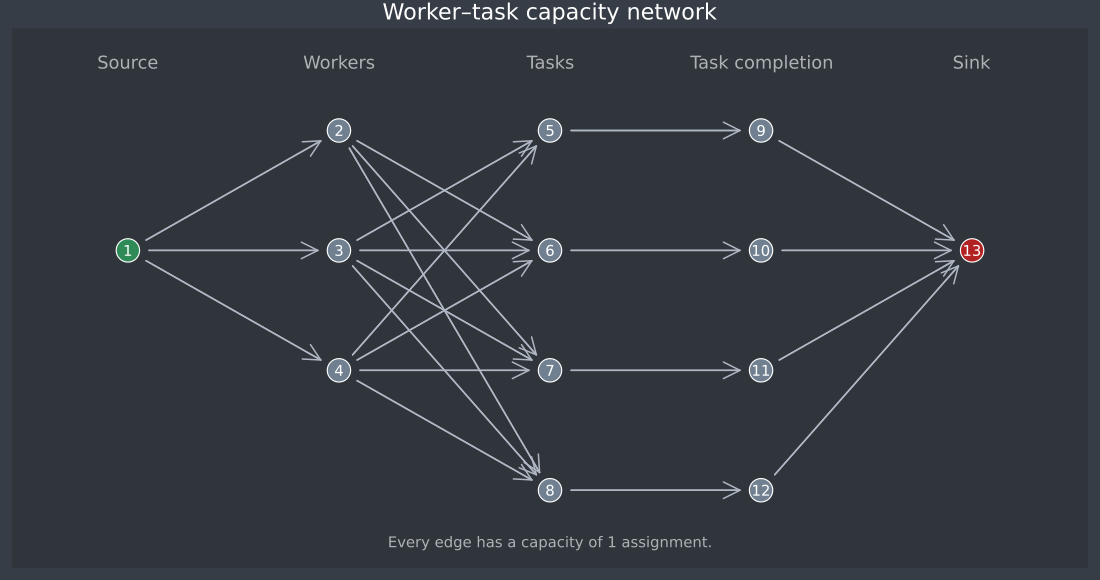

In [17]:
# Draw the available edges and capacities before computing a flow -
plot_flow_network(directed_graph, node_coordinates; 
    title = "Worker–task capacity network",  theme = :dark)


___

## Task 2: Compute and compare maximum-flow solutions

In this task, we compute the maximum flow through the worker–task network using the Ford–Fulkerson method with depth-first and breadth-first path selection, then compare the total number of assignments returned by the two searches.

Both searches increase the flow along source-to-sink paths in the residual network described in [the L5a lecture](CHEME-5800-L5a-Lecture-MaximumFlowProblems-Fall-2026.ipynb). Depth-first search takes the first augmenting path it reaches. Edmonds–Karp uses breadth-first search to select a path with the fewest residual edges. The course package names these two variants `FordFulkersonAlgorithm()` and `EdmondsKarpAlgorithm()`. Their path choices can produce different worker–task assignments even when the total completed work is the same.

[The `maximumflow(...)` function](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/#VLDataScienceMachineLearningPackage.maximumflow-Union%7BTuple%7BT%7D%2C%20Tuple%7BT%2C%20MyGraphNodeModel%2C%20MyGraphNodeModel%7D%7D%20where%20T%3C%3AAbstractGraphModel) takes the graph model, the source and sink node models, and an algorithm choice. We retrieve the node models from `directed_graph.nodes` using the `source_id` and `sink_id` defined in Task 1. Each call returns two quantities:

* **Flow value:** The total flow $|f|$ from the source to the sink, measured in assignments. We store this value in `ford_value` or `edmonds_value`.
* **Edge flows:** A dictionary containing the positive flows on individual edges, stored in `ford_flow` or `edmonds_flow`. A key `(u, v)` identifies a directed edge, and its value gives the flow $f(u,v)$ on that edge, measured in assignments. Edges missing from the dictionary carry zero flow.

Let's run both searches on the same network:


In [18]:
# Each call returns a total [assignments] and edge flows keyed by (u, v).
# Compute maximum flow with depth-first augmenting paths -
ford_value, ford_flow = maximumflow(
    directed_graph, directed_graph.nodes[source_id], directed_graph.nodes[sink_id];
    algorithm = FordFulkersonAlgorithm(),
);

# Compute maximum flow with breadth-first augmenting paths -
edmonds_value, edmonds_flow = maximumflow(
    directed_graph, directed_graph.nodes[source_id], directed_graph.nodes[sink_id];
    algorithm = EdmondsKarpAlgorithm(),
);


The scalar flow values tell us how many assignments each search found. Let's display them together; we will use the edge-flow dictionaries for the independent checks in Task 3:


In [19]:
# Compare the reported flow values -
algorithm_results = DataFrame(
    algorithm = ["Depth-first search", "Edmonds–Karp (breadth-first)"],
    maximum_flow = [ford_value, edmonds_value], # completed assignments
);
pretty_table(algorithm_results)

┌──────────────────────────────┬──────────────┐
│                    algorithm │ maximum_flow │
│                       String │      Float64 │
├──────────────────────────────┼──────────────┤
│           Depth-first search │          3.0 │
│ Edmonds–Karp (breadth-first) │          3.0 │
└──────────────────────────────┴──────────────┘


Both searches report a flow value of three assignments for the supplied network, matching the upper bound from Task 1. To establish optimality, we must also verify that the returned edge flows satisfy the capacity and conservation constraints. 
___

## Task 3: Independently verify and interpret the flow

In this task, we check the returned flows independently, identify the worker–task assignments, and use a cut-capacity bound to establish that the number of assignments is maximum.

### Check feasibility and the reported flow values

[The `validate_flow(...)` function](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/#VLDataScienceMachineLearningPackage.validate_flow-Tuple%7BAny%2C%20AbstractDict%2C%20Integer%2C%20Integer%7D) checks the edge-flow dictionary against the graph's capacities and recomputes the incoming and outgoing flow at each node. It performs three feasibility checks:

* **Edge capacities:** Every edge flow satisfies $0\leq f(u,v)\leq c(u,v)$, where $c(u,v)$ is the edge capacity. The lower flow bounds in this dataset are all zero.
* **Conservation:** Total incoming flow equals total outgoing flow at every intermediate node.
* **Source–sink balance:** The net flow leaving the source equals the net flow entering the sink.

The report's `valid` field is `true` when all three checks pass.

The report also carries a `value` field. Rather than trusting the total that the search reported, [`validate_flow(...)`](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/#VLDataScienceMachineLearningPackage.validate_flow-Tuple%7BAny%2C%20AbstractDict%2C%20Integer%2C%20Integer%7D) recomputes the flow value directly from the edge flows, as the flow leaving the source minus the flow entering it. This is the same expression we used to define $|f|$ in the lecture. We then compare this recomputed value with the total reported by the search; agreement means the reported total is consistent with the edge flows that came with it. All flow comparisons use an absolute tolerance of $10^{-8}$ assignments to allow for floating-point rounding:


In [20]:
# Independently check both edge-flow dictionaries -
flow_atol = 1e-8; # absolute tolerance for flow comparisons [assignments]
ford_report = validate_flow(directed_graph, ford_flow, source_id, sink_id; atol = flow_atol);
edmonds_report = validate_flow(directed_graph, edmonds_flow, source_id, sink_id; atol = flow_atol);

# Compare the independently calculated values with the reported totals -
ford_value_ok = isapprox(ford_report.value, ford_value; atol = flow_atol, rtol = 0);
edmonds_value_ok = isapprox(edmonds_report.value, edmonds_value; atol = flow_atol, rtol = 0);

# Compare feasibility checks; optimality requires the cut bound below -
flow_checks = DataFrame(
    check = ["Edge capacities", "Conservation", "Source–sink balance", "Reported flow value"],
    ford_fulkerson = [ford_report.capacity_ok, ford_report.conservation_ok,
        ford_report.balance_ok, ford_value_ok],
    edmonds_karp = [edmonds_report.capacity_ok, edmonds_report.conservation_ok,
        edmonds_report.balance_ok, edmonds_value_ok],
);
pretty_table(flow_checks)


┌─────────────────────┬────────────────┬──────────────┐
│               check │ ford_fulkerson │ edmonds_karp │
│              String │           Bool │         Bool │
├─────────────────────┼────────────────┼──────────────┤
│     Edge capacities │           true │         true │
│        Conservation │           true │         true │
│ Source–sink balance │           true │         true │
│ Reported flow value │           true │         true │
└─────────────────────┴────────────────┴──────────────┘


All four checks pass for both searches. The returned edge flows are feasible, and their independently calculated values agree with the totals reported in Task 2.

### Read the worker–task assignments

Both searches start with zero flow. With integer capacities, every path bottleneck and every augmentation is an integer, so the flows remain integer valued. Here, each capacity is one; a positive flow on a worker–task edge therefore identifies one complete assignment.

Let's extract the positive flows from worker nodes `2–4` to task nodes `5–8` in the Edmonds–Karp solution. Sorting the edge pairs puts the assignments in worker order:


In [21]:
# Select the worker–task edges carrying positive flow -
worker_nodes = 2:4; # worker node identifiers
task_nodes = 5:8; # task node identifiers
# A comprehension collects edges that pass the filter; sort orders the pairs.
# Julia syntax: https://docs.julialang.org/en/v1/manual/arrays/#Comprehensions
assignment_edges = sort([
    edge for (edge, value) in edmonds_flow
    if edge[1] in worker_nodes && edge[2] in task_nodes && value > flow_atol
]);

# Extract each column from the same ordered edge list -
# edge[1] is the worker node; edge[2] is the task node.
assignment_table = DataFrame(
    worker = [edge[1] for edge in assignment_edges],
    task = [edge[2] for edge in assignment_edges],
    flow = [edmonds_flow[edge] for edge in assignment_edges], # completed assignments on each edge
);
pretty_table(assignment_table)


┌────────┬───────┬─────────┐
│ worker │  task │    flow │
│  Int64 │ Int64 │ Float64 │
├────────┼───────┼─────────┤
│      2 │     6 │     1.0 │
│      3 │     5 │     1.0 │
│      4 │     7 │     1.0 │
└────────┴───────┴─────────┘


For the supplied network, worker `2` completes task `5`, worker `3` completes task `6`, and worker `4` completes task `7`. Task `8` is unassigned. Other maximum-flow solutions may assign different tasks while completing the same total number of assignments.

Let's follow these assignments through the full network. Red edges carry positive flow, and gray edges carry zero flow. In each `flow / capacity` label, the first number is the edge flow and the second is its capacity. Both quantities are measured in assignments.


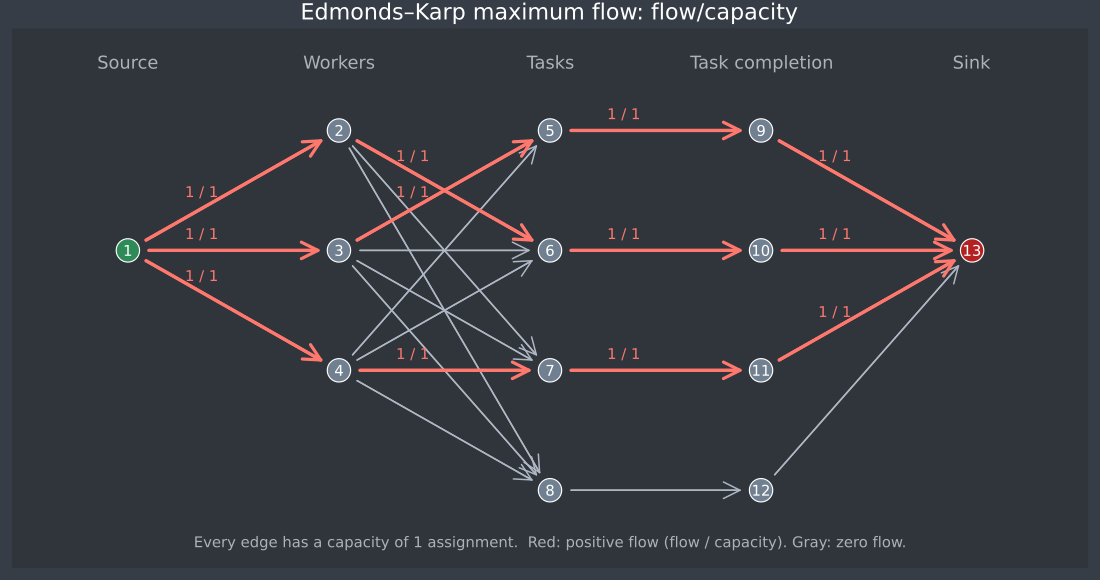

In [22]:
# Highlight positive edge flows and show each flow beside its capacity -
plot_flow_network(directed_graph, node_coordinates; 
    flow = edmonds_flow, theme = :dark,
    title = "Edmonds–Karp maximum flow: flow/capacity")


Each highlighted route carries its assignment through a task-completion node to the sink. Although an assignment traverses several edges, it contributes only one unit to the total flow entering the sink.

### Use the cut bound to establish optimality

The feasibility checks show that the assignments respect the network constraints. To show that no feasible flow can complete more work, consider the cut with $S=\{1\}$ containing only the source and $T=\mathcal{V}\setminus\{1\}$ containing all remaining nodes. The three edges crossing from $S$ to $T$ are the source-to-worker edges. The capacity of this cut is given by:

$$
c(S,T)=c(1,2)+c(1,3)+c(1,4)=1+1+1=3.
$$

Every feasible flow satisfies $|f|\leq c(S,T)$. We compute the cut capacity directly from the graph and check that both independently calculated flow values attain this bound. The tests also require the feasibility and reported-value checks to pass:


In [23]:
# Compute the capacity of the cut separating the source from all other nodes -
# bounds[2] is the upper capacity; the filter keeps edges leaving the source.
# The generator supplies each selected capacity to the sum.
# Julia syntax: https://docs.julialang.org/en/v1/manual/arrays/#Generator-Expressions
source_cut_capacity = sum((
    bounds[2] for (edge, bounds) in directed_graph.capacity
    if edge[1] == source_id && edge[2] != source_id
); init = 0.0); # upper bound on total completed assignments
println("Source-cut capacity: ", source_cut_capacity, " assignments")

# A feasible flow that attains the cut bound is maximum -
@testset "Maximum-flow verification" begin
    @test ford_report.valid && edmonds_report.valid
    @test ford_value_ok && edmonds_value_ok
    @test isapprox(ford_report.value, source_cut_capacity; atol = flow_atol, rtol = 0)
    @test isapprox(edmonds_report.value, source_cut_capacity; atol = flow_atol, rtol = 0)
end;


Source-cut capacity: 3.0 assignments
Test Summary:             | Pass  Total  Time
Maximum-flow verification |    4      4  0.0s


Both searches deliver three assignments, and the cut shows that no feasible flow can deliver more. Thus, three is the maximum for this network. Each of the three workers can take one assignment, so the fourth task goes unassigned because no worker is left.

___


## Summary

We modeled worker–task assignments as flow over a bipartite graph and verified that the supplied network can complete a maximum of three assignments.

> __Key Takeaways__
>
> * **Representing assignments as flow:** We represented each completed assignment as one unit of flow from the source to the sink. Edge capacities limited each worker and each task to one assignment, while conservation required incoming and outgoing flow to balance at intermediate nodes.
>
> * **Computing and interpreting maximum flow:** We applied the Ford–Fulkerson method with depth-first and breadth-first path selection to the same network and obtained three assignments with both searches. We used positive worker–task flows to identify individual assignments and the total flow to count completed work.
>
> * **Verifying feasibility and optimality:** We independently checked capacities, conservation, source–sink balance, and agreement with the reported flow values. Both feasible flows reached the source-cut capacity of three, proving that the supplied network cannot complete more than three assignments.

In [the L5b lab](../L5b/CHEME-5800-L5b-Lab-MaximumFlowSensitivity-Fall-2026.ipynb), we will change edge capacities and examine how those changes affect the maximum number of assignments.

___